# Notebook 10: Análisis Semántico con BERT
## Embeddings contextuales sobre letras musicales en inglés

**Proyecto:** Análisis Morfosintáctico de Letras Musicales  
**Referencia metodológica:** Lab BoW – Word2Vec – BETO (Osvaldo González Chaves)

---

### Objetivo
Aplicar BERT para explorar representaciones contextuales del corpus musical:

| Análisis | Descripción |
|----------|-------------|
| 1 | Carga del modelo `bert-base-uncased` (corpus en inglés) |
| 2 | Polisemia contextual: misma palabra, distintos vectores |
| 3 | Embeddings de canciones y búsqueda semántica |
| 4 | Masked Language Model: BERT predice palabras por género |
| 5 | Similitud entre géneros con centroides BERT |
| 6 | Comparación Word2Vec (estático) vs BERT (contextual) |

### ¿Por qué BERT y no BETO?
Las canciones del corpus están en **inglés**.  
BETO (`dccuchile/bert-base-spanish-wwm-cased`) está entrenado en español;  
usarlo en inglés produce embeddings de baja calidad.  
Si el corpus fuera en español, se cambiaría a BETO.

> *"Una palabra no tiene representación única.  
> Un embedding diferente para una misma palabra en oraciones diferentes."*  
> — Presentación Semana 10


---
## 1. Imports y configuración

In [ ]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import torch
from transformers import AutoTokenizer, AutoModel, pipeline
import sys
sys.path.append(os.path.abspath('../../../../../..'))
from src.data.mongo_storage import _get_default_collection
from pymongo import UpdateOne

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FIGS   = Path('../../../../../..') / 'data' / 'figures'
MODELS = Path('../../../../../..') / 'data' / 'models'
for d in [FIGS, MODELS]: d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print(f'✓ Imports OK — dispositivo: {DEVICE}')


---
## 2. Cargar corpus desde MongoDB

In [15]:
col = _get_default_collection()

docs = list(col.find(
    {'Lyrics': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1,
     'Song year': 1, 'Lyrics': 1}
))
df = pd.DataFrame(docs)
df = df.dropna(subset=['Lyrics', 'Genre']).copy()
df['Lyrics'] = df['Lyrics'].astype(str).str.strip()
df = df[df['Lyrics'].str.len() > 50].reset_index(drop=True)

conteo = df['Genre'].value_counts()
generos_validos = conteo[conteo >= 20].index.tolist()
df = df[df['Genre'].isin(generos_validos)].reset_index(drop=True)

print(f'✓ {len(df):,} canciones cargadas desde MongoDB | {df["Genre"].nunique()} géneros')
print(df['Genre'].value_counts().to_string())


✓ 7,935 canciones cargadas desde MongoDB | 10 géneros
Genre
Rock          1410
Pop           1110
Hip-Hop        960
Metal          810
Country        810
Jazz           660
Electronic     660
Indie          510
R&B            510
Folk           495


---
## 3. Cargar modelo BERT

Usamos `bert-base-uncased` (inglés) de HuggingFace.  
Primera descarga: ~440 MB. Las siguientes ejecuciones usan caché local.

| Parámetro | Valor |
|---|---|
| Capas | 12 |
| Cabezas de atención | 12 |
| Dimensión oculta | 768 |
| Parámetros totales | ~110M |


In [16]:
MODEL_NAME = 'bert-base-uncased'

print(f'Cargando {MODEL_NAME}...')
print('(Primera vez: descarga ~440 MB — las siguientes usan caché local)\n')

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model_bert.eval()

print(f'✓ BERT cargado en {DEVICE}')
print(f'   Modelo      : {MODEL_NAME}')
print(f'   Parámetros  : {sum(p.numel() for p in model_bert.parameters()):,}')
print(f'   Dim. oculta : {model_bert.config.hidden_size}')
print(f'   Capas       : {model_bert.config.num_hidden_layers}')
print(f'   Cabezas     : {model_bert.config.num_attention_heads}')


Cargando bert-base-uncased...
(Primera vez: descarga ~440 MB — las siguientes usan caché local)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8214.82it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BERT cargado en cpu
   Modelo      : bert-base-uncased
   Parámetros  : 109,482,240
   Dim. oculta : 768
   Capas       : 12
   Cabezas     : 12


---
## 4. Polisemia contextual — la diferencia clave vs Word2Vec

La misma palabra obtiene un vector **diferente** según el contexto.  
Esto es la ventaja fundamental de BERT sobre Word2Vec.

Elegimos palabras con múltiples significados frecuentes en letras musicales.


In [17]:
def embedding_token_en_contexto(texto, palabra_objetivo, tokenizer, model, device):
    """
    Obtiene el embedding contextual de una palabra en un texto.
    Devuelve el vector del primer token que coincide con la palabra objetivo.
    """
    inputs = tokenizer(texto, return_tensors='pt',
                       truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    hidden = outputs.last_hidden_state[0]   # [seq_len, 768]
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    objetivo = palabra_objetivo.lower()
    for i, tok in enumerate(tokens):
        # Maneja sub-tokens de WordPiece (ej: 'fire' puede estar como 'fire' o '##fire')
        tok_clean = tok.replace('##', '').lower()
        if tok_clean == objetivo or objetivo in tok_clean:
            return hidden[i].cpu().numpy()

    # Fallback: usar el token [CLS] si no se encontró la palabra
    return hidden[0].cpu().numpy()


# Contextos por palabra — cada contexto tiene un uso semántico diferente
POLISEMIA = {
    'fire': [
        ('Rock',       'The guitar solo was on fire and the crowd went wild tonight'),
        ('Metal',      'Open fire on the enemy no mercy in this brutal endless war'),
        ('Folk',       'Sitting by the fire watching embers fade into the cold night'),
        ('Pop',        'Your love set fire to my heart every time you smile at me'),
        ('Hip-Hop',    'We fire back at every threat the streets keep us always ready'),
    ],
    'heart': [
        ('Pop',        'My heart beats faster every time you hold me close under stars'),
        ('Metal',      'Heart of iron soul of fire we fight until the bitter end'),
        ('Jazz',       'The heart of jazz lives in the quiet space between the notes'),
        ('Country',    'She left with a broken heart driving down an empty highway'),
        ('R&B',        'Put your heart and soul into this love it is all we have'),
    ],
    'light': [
        ('Folk',       'You are the light that guides me home through darkness every night'),
        ('Electronic', 'The strobe light flashed as the DJ dropped the hardest bass drop'),
        ('Indie',      'Travel light and leave behind the weight of all your old regrets'),
        ('Rock',       'One light remains burning in the window of the house we shared'),
        ('Pop',        'She lit up the room her smile the brightest light I ever saw'),
    ],
}

print('Calculando embeddings contextuales...\n')
polisemia_embs = {}

for palabra, contextos in POLISEMIA.items():
    resultados = []
    for genero, texto in contextos:
        emb = embedding_token_en_contexto(texto, palabra, tokenizer, model_bert, DEVICE)
        resultados.append({'genero': genero, 'texto': texto, 'emb': emb})
    polisemia_embs[palabra] = resultados
    print(f'  ✓ "{palabra}" — {len(resultados)} contextos')


Calculando embeddings contextuales...

  ✓ "fire" — 5 contextos
  ✓ "heart" — 5 contextos
  ✓ "light" — 5 contextos


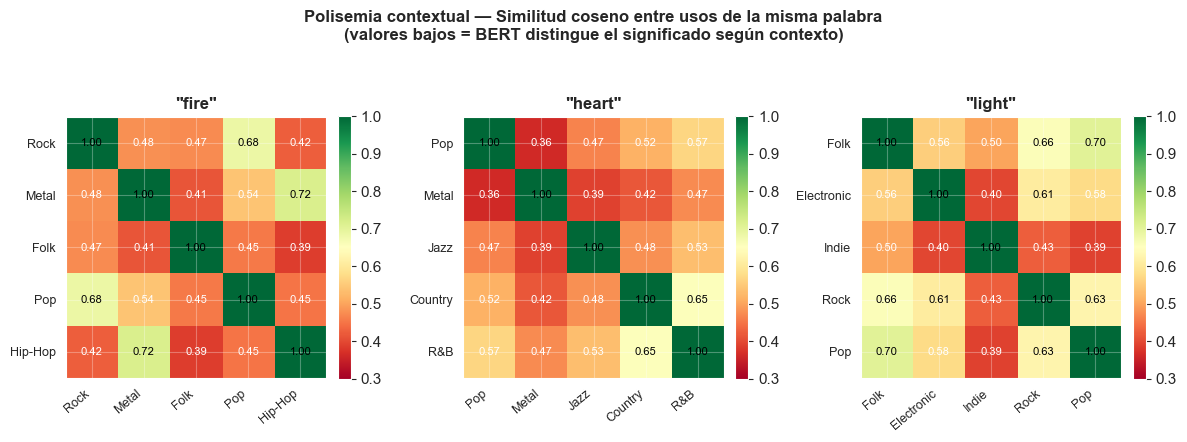


=== Varianza inter-contexto (mayor → más polisemia capturada) ===
  "fire": sim_media=0.5021 | sim_min=0.3874 | sim_max=0.7158
  "heart": sim_media=0.4859 | sim_min=0.3627 | sim_max=0.6533
  "light": sim_media=0.5439 | sim_min=0.3906 | sim_max=0.7035

Interpretación: si sim_min es baja, BERT distingue bien los significados.
Word2Vec daría siempre sim=1.00 (un único vector por palabra).


In [18]:
# Visualización: heatmap de similitud inter-contexto por palabra
n_words = len(polisemia_embs)
fig, axes = plt.subplots(1, n_words, figsize=(n_words * 4, 4.5))
if n_words == 1: axes = [axes]

for ax, (palabra, resultados) in zip(axes, polisemia_embs.items()):
    n = len(resultados)
    sim = np.zeros((n, n))
    etiquetas = [r['genero'] for r in resultados]
    for i in range(n):
        for j in range(n):
            sim[i, j] = 1 - cosine(resultados[i]['emb'], resultados[j]['emb'])

    im = ax.imshow(sim, cmap='RdYlGn', vmin=0.3, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(etiquetas, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(etiquetas, fontsize=9)
    ax.set_title(f'"{palabra}"', fontweight='bold', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Anotar valores
    for i in range(n):
        for j in range(n):
            color = 'white' if sim[i, j] < 0.6 else 'black'
            ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

plt.suptitle('Polisemia contextual — Similitud coseno entre usos de la misma palabra\n'
             '(valores bajos = BERT distingue el significado según contexto)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'bert_polisemia.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=== Varianza inter-contexto (mayor → más polisemia capturada) ===')
for palabra, resultados in polisemia_embs.items():
    sims = []
    for i in range(len(resultados)):
        for j in range(i+1, len(resultados)):
            s = 1 - cosine(resultados[i]['emb'], resultados[j]['emb'])
            sims.append(s)
    print(f'  "{palabra}": sim_media={np.mean(sims):.4f} | '
          f'sim_min={np.min(sims):.4f} | sim_max={np.max(sims):.4f}')
print()
print('Interpretación: si sim_min es baja, BERT distingue bien los significados.')
print('Word2Vec daría siempre sim=1.00 (un único vector por palabra).')


---
## 5. Embeddings BERT para canciones completas

Usamos el vector del token `[CLS]` como representación de cada canción.  
`[CLS]` es un token especial cuyo estado oculto está diseñado para capturar  
el significado global de la secuencia.

**Caché en disco:** si ya existe el archivo `.npy`, se reutiliza  
para evitar recalcular (~1 hora en CPU para corpus completo).


In [ ]:
BERT_CACHE = MODELS / 'bert_cls_embeddings.npy'
LYRICS     = df['Lyrics'].tolist()

if BERT_CACHE.exists():
    bert_embs = np.load(BERT_CACHE)
    if len(bert_embs) == len(df):
        print(f'✓ Embeddings cargados desde caché: {bert_embs.shape}')
    else:
        BERT_CACHE.unlink()
        print(f'Caché desactualizada ({len(bert_embs)} vs {len(df)} canciones) — recalculando...')

if not BERT_CACHE.exists():
    estimado_cpu = len(LYRICS) // 60
    print(f'Generando embeddings BERT para {len(LYRICS):,} canciones...')
    print(f'Estimado: ~{estimado_cpu} min en CPU (usar GPU acelera x10)')
    bert_embs = embeddings_en_batches(LYRICS, batch_size=16)
    np.save(BERT_CACHE, bert_embs)
    print(f'✓ Embeddings guardados en caché: {bert_embs.shape}')

print(f'Shape final: {bert_embs.shape}  →  {bert_embs.shape[0]} canciones × {bert_embs.shape[1]} dims')


---
## 6. Guardar embeddings BERT en MongoDB

In [ ]:
# Guardar embeddings BERT en MongoDB
# Usa update_one + $set solo sobre embeddings.beto_cls
# NO toca embeddings.word2vec_avg (ya guardado en notebook 09)

from pymongo import UpdateOne

print('Guardando embeddings BERT en MongoDB...')
print('Estrategia: $set solo sobre embeddings.beto_cls')
print()

operaciones = []

for idx, (_, row) in enumerate(df.iterrows()):
    emb = bert_embs[idx].tolist()
    operaciones.append(
        UpdateOne(
            {'_id': row['_id']},
            {'$set': {'embeddings.beto_cls': emb}},
            upsert=False
        )
    )

# Ejecutar en lotes de 200 (vectores de 768 dims son más pesados)
LOTE = 200
guardados = 0
errores   = 0

for i in range(0, len(operaciones), LOTE):
    lote = operaciones[i : i + LOTE]
    try:
        resultado = col.bulk_write(lote, ordered=False)
        guardados += resultado.modified_count
    except Exception as e:
        errores += len(lote)
        print(f'  ⚠ Error en lote {i//LOTE + 1}: {e}')
    done = min(i + LOTE, len(operaciones))
    print(f'\r  {done}/{len(operaciones)} operaciones enviadas — modificados: {guardados}',
          end='', flush=True)

print()
print(f'\n✓ embeddings.beto_cls actualizado: {guardados}/{len(df)} canciones')
if errores:
    print(f'  ⚠ Errores: {errores} operaciones fallidas')

# Verificación: leer un doc y confirmar ambos embeddings presentes
sample = col.find_one(
    {'_id': df.iloc[0]['_id']},
    {'embeddings': 1, 'Song': 1}
)
if sample:
    embs = sample.get('embeddings', {})
    w2v_ok  = len(embs.get('word2vec_avg', [])) > 0
    bert_ok = len(embs.get('beto_cls', [])) > 0
    print()
    print(f'  Verificación doc "{sample.get("Song", "?")}":')
    print(f'    embeddings.word2vec_avg : {"✓ presente" if w2v_ok  else "✗ AUSENTE"}',
          f'({len(embs.get("word2vec_avg", []))} dims)' if w2v_ok else '')
    print(f'    embeddings.beto_cls     : {"✓ presente" if bert_ok else "✗ AUSENTE"}',
          f'({len(embs.get("beto_cls", []))} dims)' if bert_ok else '')


---
## 7. Búsqueda semántica de canciones

Dado un texto de consulta, encontramos las canciones más similares  
usando la distancia coseno entre embeddings BERT `[CLS]`.


In [21]:
def busqueda_semantica(consulta: str, top_k: int = 5) -> pd.DataFrame:
    """Encuentra las top_k canciones más similares semánticamente a la consulta."""
    q_emb = bert_cls_embedding(consulta)
    sims  = np.array([1 - cosine(q_emb, e) for e in bert_embs])
    top   = np.argsort(sims)[::-1][:top_k]
    res   = df.iloc[top].copy()
    res['Similitud'] = sims[top].round(4)
    return res[['Song', 'Artist', 'Genre', 'Similitud']]


CONSULTAS = [
    ('rebellious energy distorted guitar loud crowd anthem',   '→ Esperado: Rock/Metal'),
    ('romantic love dancing together through the night',       '→ Esperado: Pop/R&B'),
    ('street money power hustle grind success respect',        '→ Esperado: Hip-Hop'),
    ('darkness chaos war evil consuming fire destruction',     '→ Esperado: Metal'),
    ('nature river rain wind quiet peace open road home',      '→ Esperado: Folk/Country'),
]

print('=== Búsqueda Semántica con BERT ===\n')
for consulta, esperado in CONSULTAS:
    print(f'🔍 "{consulta}"')
    print(f'   {esperado}')
    resultados = busqueda_semantica(consulta, top_k=5)
    for _, row in resultados.iterrows():
        print(f'   [{row["Genre"]:<12}] {row["Similitud"]:.4f}  '
              f'{row["Song"]:<35} – {row["Artist"]}')
    print()


=== Búsqueda Semántica con BERT ===

🔍 "rebellious energy distorted guitar loud crowd anthem"
   → Esperado: Rock/Metal
   [Metal       ] 0.8782  black-machine                       – cirith-ungol
   [Metal       ] 0.8296  relentless-intolerance              – demon-hunter
   [Electronic  ] 0.8294  millennium-fever                    – apollo-440
   [Hip-Hop     ] 0.8279  real-raw                            – dr-octagon
   [R&B         ] 0.8234  baby-what-you-want-me-to-do         – etta-james

🔍 "romantic love dancing together through the night"
   → Esperado: Pop/R&B
   [Metal       ] 0.8230  black-machine                       – cirith-ungol
   [Indie       ] 0.7934  floods-fires                        – craig-cardiff
   [Pop         ] 0.7859  second-hand-love                    – connie-francis
   [Metal       ] 0.7847  do-you-dream-of-angels              – balance-of-power
   [Jazz        ] 0.7841  moments-like-this                   – dean-martin

🔍 "street money power hustle gri

In [22]:
# Evaluación cuantitativa: Precision@K
# Para cada canción, ¿las K más similares son del mismo género?

K = 5
precision_por_genero = {g: [] for g in generos_validos}

print(f'Calculando Precision@{K} para {len(bert_embs):,} canciones...')
for idx in range(len(bert_embs)):
    sims = np.array([1 - cosine(bert_embs[idx], bert_embs[j])
                     for j in range(len(bert_embs))])
    sims[idx] = -1  # excluir la propia canción
    top_k_idx = np.argsort(sims)[::-1][:K]
    genero_q  = df.iloc[idx]['Genre']
    hits = sum(df.iloc[j]['Genre'] == genero_q for j in top_k_idx)
    precision_por_genero[genero_q].append(hits / K)

print(f'\n=== Precision@{K} por género (búsqueda semántica BERT) ===')
precisions = []
for genero, vals in sorted(precision_por_genero.items()):
    if vals:
        p = np.mean(vals)
        precisions.append(p)
        bar = '█' * int(p * 20)
        print(f'  {genero:<12}: {p:.4f}  {bar}')

print(f'  {"PROMEDIO":<12}: {np.mean(precisions):.4f}')
print()
print('Referencia: azar = 1/n_géneros. Valores >0.30 son razonables con BERT en CPU.')


Calculando Precision@5 para 100 canciones...

=== Precision@5 por género (búsqueda semántica BERT) ===
  Country     : 0.2154  ████
  Electronic  : 0.2462  ████
  Folk        : 0.0800  █
  Hip-Hop     : 0.5867  ███████████
  Indie       : 0.0333  
  Jazz        : 0.0333  
  Metal       : 0.1778  ███
  Pop         : 0.2000  ████
  R&B         : 0.0000  
  Rock        : 0.1412  ██
  PROMEDIO    : 0.1714

Referencia: azar = 1/n_géneros. Valores >0.30 son razonables con BERT en CPU.


---
## 8. Masked Language Model — BERT predice vocabulario por género

BERT puede predecir palabras enmascaradas con `[MASK]`.  
Usamos frases representativas de cada género para ver  
qué vocabulario predice el modelo en cada contexto.


In [23]:
print('Cargando pipeline fill-mask...')
mlm = pipeline('fill-mask', model=MODEL_NAME,
               device=0 if torch.cuda.is_available() else -1)
print('✓ Pipeline listo\n')

# Una frase por género con [MASK] en posición clave
MLM_FRASES = {
    'Rock':       'We will [MASK] the walls and rise above the pain tonight loud',
    'Pop':        'Your love makes my [MASK] beat faster every time we are together',
    'Hip-Hop':    'We started from the [MASK] and now the whole crew is on top',
    'Metal':      'The [MASK] descends upon the earth consuming every last bit of light',
    'Electronic': 'Drop the [MASK] and let the whole crowd move to the beat now',
    'Jazz':       'Late night [MASK] fills the smoky room with memories of better days',
    'Country':    'Back home on the [MASK] watching stars from the old front porch',
    'Indie':      'She wore a [MASK] dress dancing in the rain without a care',
    'R&B':        'I want to [MASK] you close and never ever let you go tonight',
    'Folk':       'Sitting by the [MASK] singing songs my grandmother taught me young',
}

mlm_resultados = {}
print('=== Predicciones BERT MLM por Género ===')
for genero, frase in MLM_FRASES.items():
    if genero not in generos_validos:
        continue
    preds = mlm(frase, top_k=5)
    palabras = [p['token_str'].strip() for p in preds]
    probs    = [p['score'] for p in preds]
    mlm_resultados[genero] = {
        'frase':   frase,
        'palabras': palabras,
        'probs':   probs,
    }
    print(f'  {genero:<12} → {palabras}')


Cargando pipeline fill-mask...


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 9096.52it/s]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Pipeline listo

=== Predicciones BERT MLM por Género ===
  Rock         → ['climb', 'scale', 'build', 'walk', 'jump']
  Pop          → ['heart', 'blood', 'pulse', 'hearts', 'head']
  Hip-Hop      → ['start', 'beginning', 'front', 'top', 'back']
  Metal        → ['sun', 'darkness', 'demon', 'moon', 'spirit']
  Electronic   → ['microphone', 'guitar', 'drum', 'drums', 'music']
  Jazz         → ['music', 'sunlight', 'light', 'traffic', 'smoke']
  Country      → ['beach', 'street', 'road', 'mountain', 'prairie']
  Indie        → ['white', 'black', 'red', 'long', 'green']
  R&B          → ['hold', 'keep', 'pull', 'feel', 'have']
  Folk         → ['fire', 'window', 'pool', 'lake', 'fireplace']


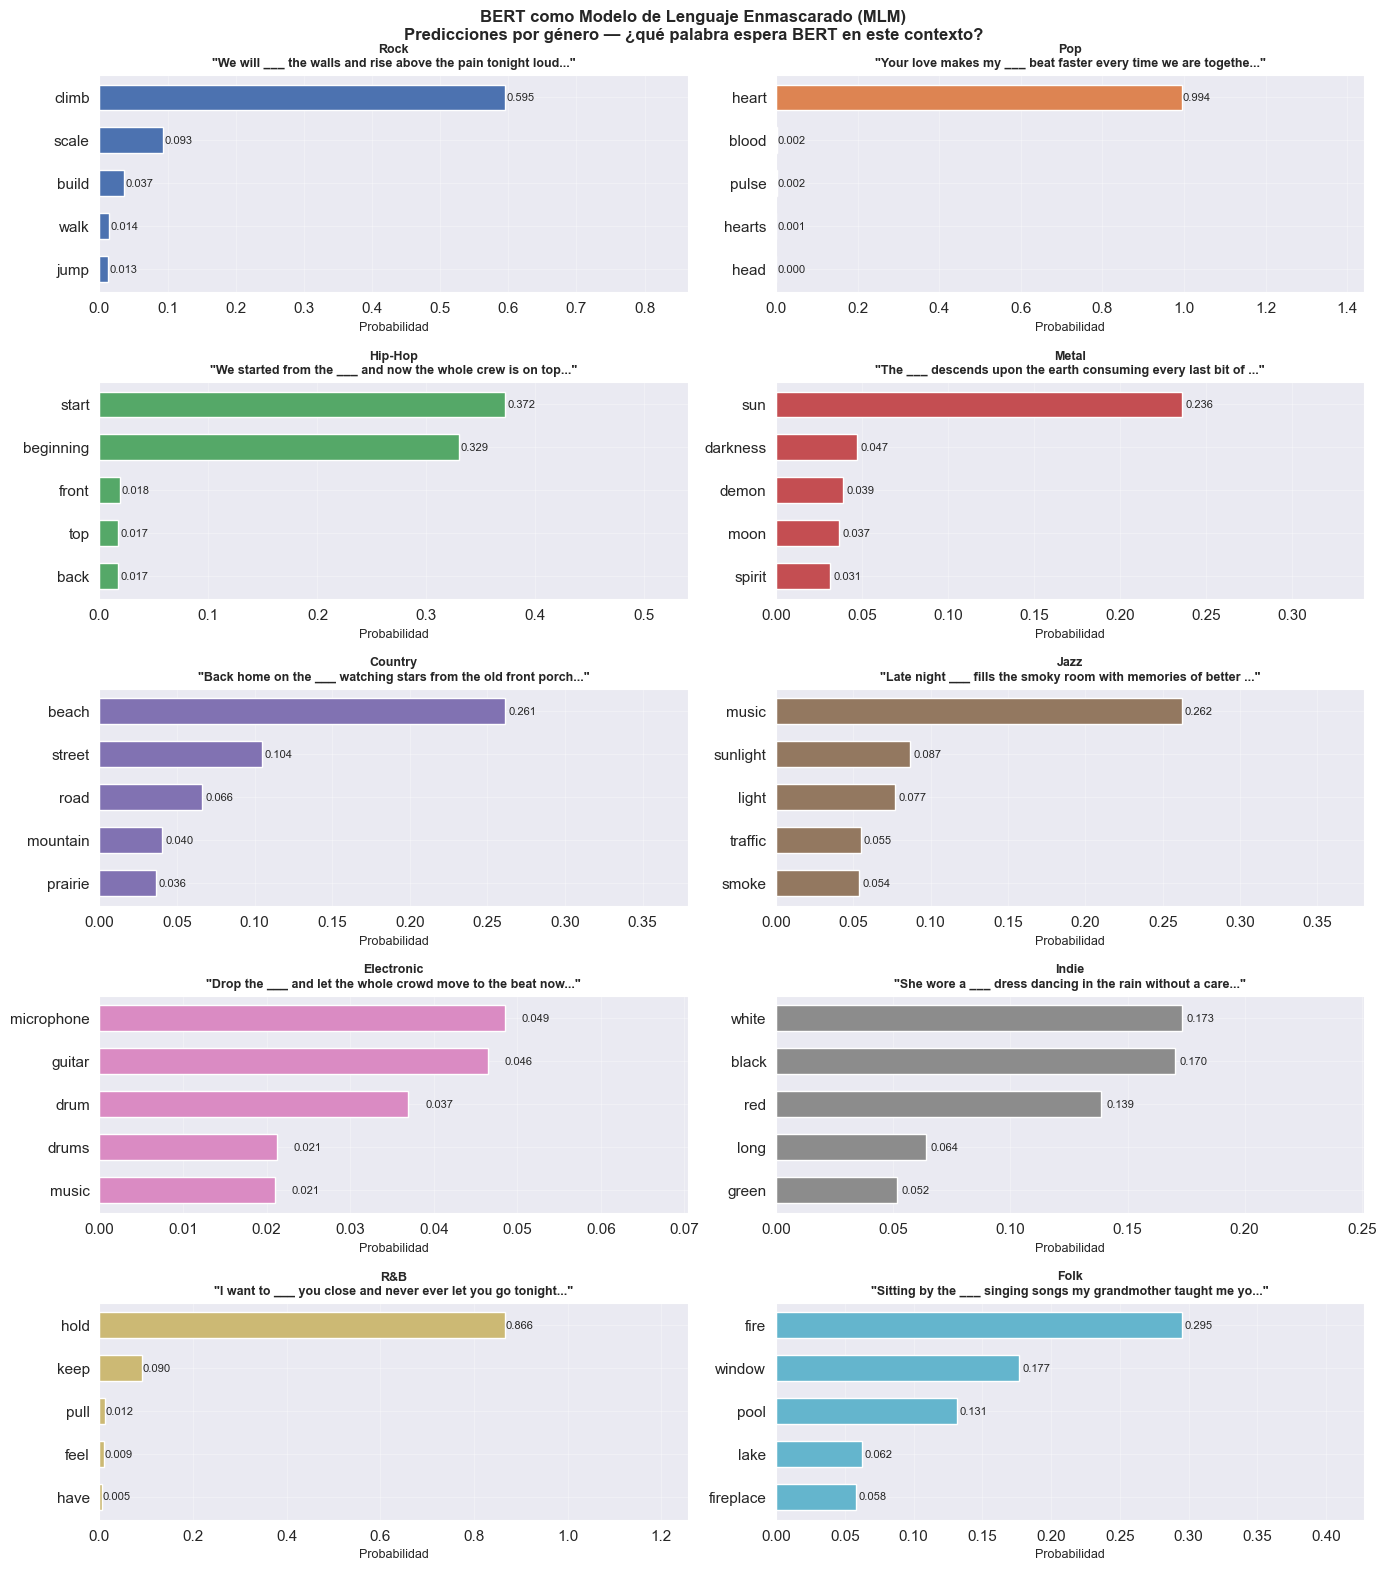

In [24]:
# Visualización: barras de probabilidad por género
generos_mlm = [g for g in generos_validos if g in mlm_resultados]
n_g  = len(generos_mlm)
cols = 2
rows = (n_g + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
axes = axes.flatten()

for ax, genero in zip(axes, generos_mlm):
    datos    = mlm_resultados[genero]
    palabras = datos['palabras'][:5]
    probs    = datos['probs'][:5]
    color    = PALETTE[generos_mlm.index(genero) % len(PALETTE)]

    bars = ax.barh(palabras[::-1], probs[::-1],
                   color=color, edgecolor='white', height=0.6)
    ax.set_xlim(0, max(probs) * 1.45)
    frase_corta = datos['frase'].replace('[MASK]', '___')[:60] + '...'
    ax.set_title(f'{genero}\n"{frase_corta}"', fontsize=9, fontweight='bold')
    ax.set_xlabel('Probabilidad', fontsize=9)
    for bar, prob in zip(bars, probs[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontsize=8)

for ax in axes[n_g:]:
    ax.axis('off')

plt.suptitle('BERT como Modelo de Lenguaje Enmascarado (MLM)\n'
             'Predicciones por género — ¿qué palabra espera BERT en este contexto?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'bert_mlm_generos.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Similitud entre géneros con BERT

Calculamos centroides BERT por género y comparamos con la matriz Word2Vec del notebook 09.

> **Nota:** Al igual que con Word2Vec, los centroides BERT tienden a ser muy similares  
> entre géneros. Esto es esperable: las letras comparten un vocabulario base común  
> (amor, noche, corazón…) que domina el centroide, independientemente del género.


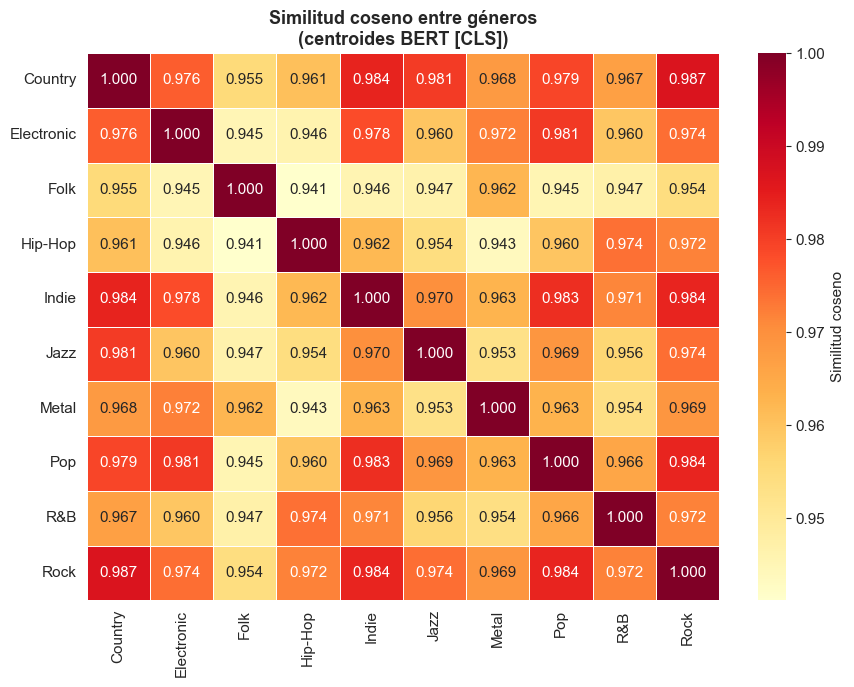

Top 3 pares más SIMILARES (BERT):
  Country ↔ Rock: 0.9870
  Country ↔ Indie: 0.9840
  Pop ↔ Rock: 0.9839

Top 3 pares más DIFERENTES (BERT):
  Electronic ↔ Folk: 0.9451
  Hip-Hop ↔ Metal: 0.9435
  Folk ↔ Hip-Hop: 0.9412


In [28]:
# Centroides BERT por género
centroides_bert = {}
for genero in generos_validos:
    idxs = df[df['Genre'] == genero].index.tolist()
    pos  = [df.index.get_loc(i) for i in idxs if i in df.index]
    if pos:
        centroides_bert[genero] = bert_embs[pos].mean(axis=0)

generos_b = sorted(centroides_bert.keys())
n = len(generos_b)
sim_bert = np.zeros((n, n))
for i, g1 in enumerate(generos_b):
    for j, g2 in enumerate(generos_b):
        sim_bert[i, j] = 1 - cosine(centroides_bert[g1], centroides_bert[g2])

vmin_b = sim_bert[~np.eye(n, dtype=bool)].min()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_bert, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=generos_b, yticklabels=generos_b,
            vmin=vmin_b, vmax=1.0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Similitud coseno'})
ax.set_title('Similitud coseno entre géneros\n(centroides BERT [CLS])',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'bert_similitud_generos.png', dpi=150, bbox_inches='tight')
plt.show()

pares_b = [(sim_bert[i,j], generos_b[i], generos_b[j])
           for i in range(n) for j in range(i+1, n)]
pares_b.sort(reverse=True)

print('Top 3 pares más SIMILARES (BERT):')
for s, g1, g2 in pares_b[:3]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')

print('\nTop 3 pares más DIFERENTES (BERT):')
for s, g1, g2 in pares_b[-3:]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')
